# EDA — GSO/NSO Việt Nam

Phân tích `gso.json`: quy mô, domain (kể cả domain ghép bằng `;`), thời gian, chất lượng dữ liệu, độ dài nội dung và mẫu bài.

In [1]:
from pathlib import Path
import sys
search_roots = (Path.cwd(), *Path.cwd().parents)
module_dir = next((p for root in search_roots for p in (root, root / "loc_crawl" / "notebooks") if (p / "eda_utils.py").exists()), None)
if module_dir is None: raise FileNotFoundError("Không tìm thấy eda_utils.py")
sys.path.insert(0, str(module_dir))

from eda_utils import *
SOURCE_KEY = "gso"
df, atomic_domains, data_path = load_source(SOURCE_KEY)
print(f"Đã tải {len(df):,} bài từ {data_path}")

Đã tải 2,500 bài từ C:\NC KHOA HỌC - THẦY LONG\Fact-checking\loc_crawl\output\gso.json


## 1. Tổng quan và mẫu dữ liệu

In [2]:
overview = source_overview(df, atomic_domains, data_path)

**File:** `C:\NC KHOA HỌC - THẦY LONG\Fact-checking\loc_crawl\output\gso.json`  
**Kích thước:** 32.09 MB

,Chỉ số,Giá trị
0,Số bài,"2,500"
1,Số domain nguyên bản,27
2,Số domain sau khi tách,5
3,Bài đa-domain,701
4,Ngày hợp lệ,"2,500 (100.0%)"
5,Ngày nhỏ nhất,2019-12-25
6,Ngày lớn nhất,2026-07-16
7,ID trùng,0
8,URL trùng,0


,id,source_name,domain,publish_date,claim,label,url
0,9e3621825770c6c27133adabf9734e68,GSO/NSO Việt Nam,Kinh tế,2026-07-16,Chỉ số sản xuất công nghiệp tháng Ba năm 2026,TRUE,https://www.nso.gov.vn/du-lieu-va-so-lieu-thong-ke/2026/04/chi-so-san-xuat-cong-nghiep-thang-ba-...
1,d2e839a35c60e41e92ea85e113f87c73,GSO/NSO Việt Nam,Kinh tế,2026-07-16,"Chỉ số giá tiêu dùng, chỉ số giá vàng và chỉ số giá đô la Mỹ tháng Ba và quý I năm 2026",TRUE,https://www.nso.gov.vn/du-lieu-va-so-lieu-thong-ke/2026/04/chi-so-gia-tieu-dung-chi-so-gia-vang-...
2,4d5cbbbf5f24975ee2e9953dd28ef8a9,GSO/NSO Việt Nam,Kinh tế; Tài khoản quốc gia và tài chính; Xã hội môi trường và đơn vị hành chính,2026-07-16,Báo cáo tình hình kinh tế - xã hội tháng Tư và 4 tháng đầu năm 2026,TRUE,https://www.nso.gov.vn/bai-top/2026/05/bao-cao-tinh-hinh-kinh-te-xa-hoi-thang-tu-va-4-thang-dau-...
3,823fa12d690adb9235725764929e424a,GSO/NSO Việt Nam,Kinh tế,2026-07-16,"Chỉ số giá tiêu dùng, chỉ số giá vàng và chỉ số giá đô la Mỹ tháng Mười Hai, quý IV và năm 2025",TRUE,https://www.nso.gov.vn/du-lieu-va-so-lieu-thong-ke/2026/01/chi-so-gia-tieu-dung-chi-so-gia-vang-...
4,9b4f087b53ae09230214f0e4392ea49e,GSO/NSO Việt Nam,Kinh tế,2026-07-15,Thắng lợi vụ lúa đông xuân năm 2026: nhìn từ giải pháp nâng cao năng suất,TRUE,https://www.nso.gov.vn/du-lieu-va-so-lieu-thong-ke/2026/07/thang-loi-vu-lua-dong-xuan-nam-2026-n...


## 2. Phân bố domain

**Phân bố domain sau khi tách dấu `;`**

,domain,số_bài,tỷ_lệ_trên_bài
0,Kinh tế,1798,0.72
1,Xã hội môi trường và đơn vị hành chính,871,0.35
2,Tài khoản quốc gia và tài chính,742,0.30
3,Dân số và lao động,523,0.21
4,Tổng điều tra,95,0.04


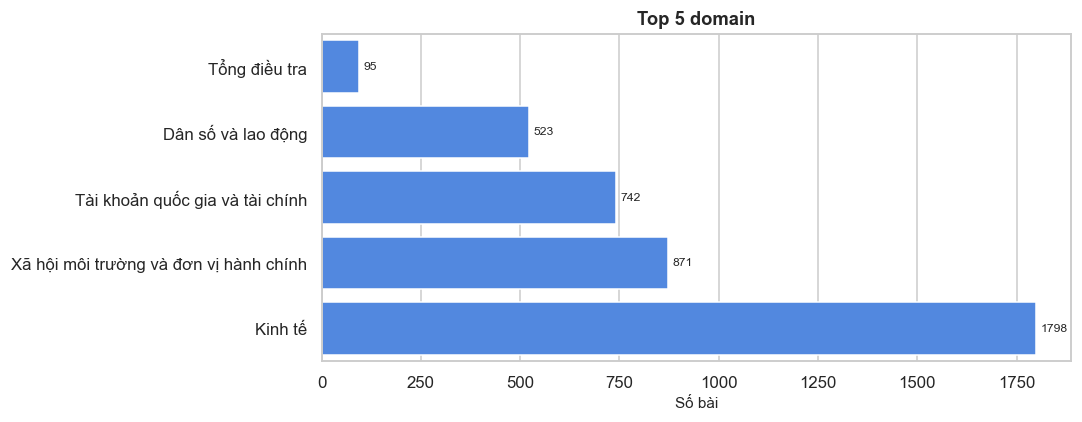

**Tổ hợp domain nguyên bản phổ biến**

,domain_nguyên_bản,số_bài
0,Kinh tế,1136
1,Xã hội môi trường và đơn vị hành chính,251
2,Dân số và lao động,207
3,Kinh tế; Tài khoản quốc gia và tài chính; Xã hội môi trường và đơn vị hành chính,199
4,Kinh tế; Dân số và lao động; Xã hội môi trường và đơn vị hành chính; Tài khoản quốc gia và tài c...,154
5,Tài khoản quốc gia và tài chính,154
6,Kinh tế; Xã hội môi trường và đơn vị hành chính; Tài khoản quốc gia và tài chính,83
7,Kinh tế; Xã hội môi trường và đơn vị hành chính,58
8,Kinh tế; Xã hội môi trường và đơn vị hành chính; Dân số và lao động; Tài khoản quốc gia và tài c...,56
9,Tổng điều tra,51


,số_domain_trên_bài,số_bài
0,1,1799
1,2,142
2,3,297
3,4,255
4,5,7


In [3]:
domain_counts = source_domain_analysis(df, atomic_domains)

## 3. Phân bố thời gian và domain theo năm

,trạng_thái_ngày,số_bài,tỷ_lệ
0,Hợp lệ,2500,1.00
1,Thiếu/không parse được,0,0.00


,year,số_bài
0,2019,58
1,2020,572
2,2021,298
3,2022,200
4,2023,388
5,2024,686
6,2025,154
7,2026,144


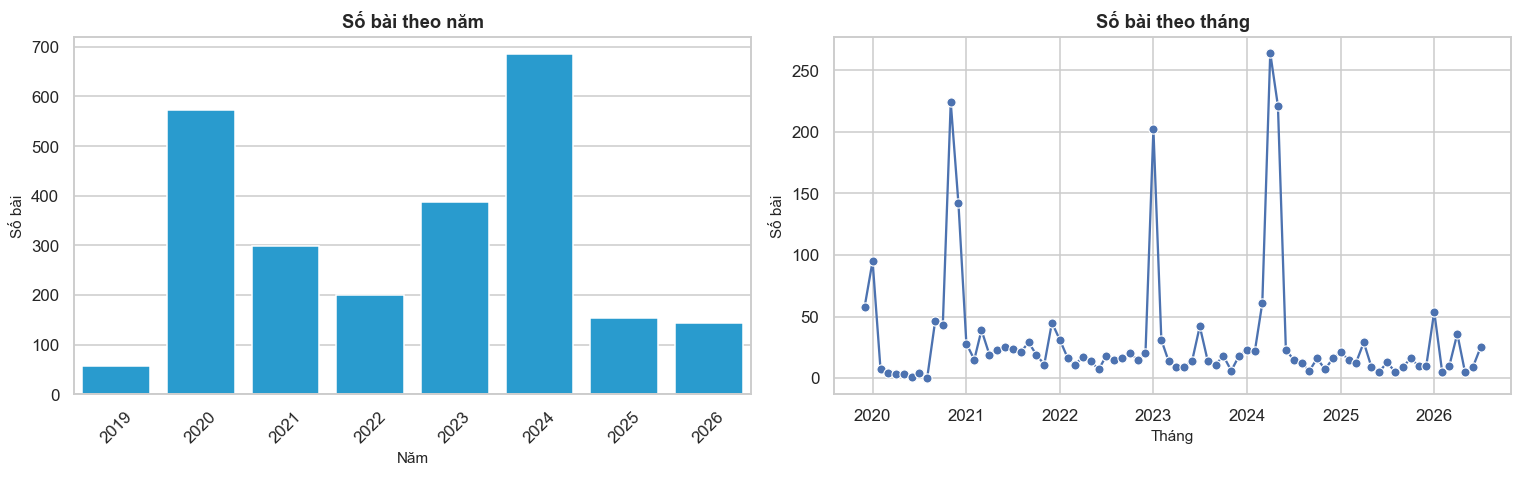

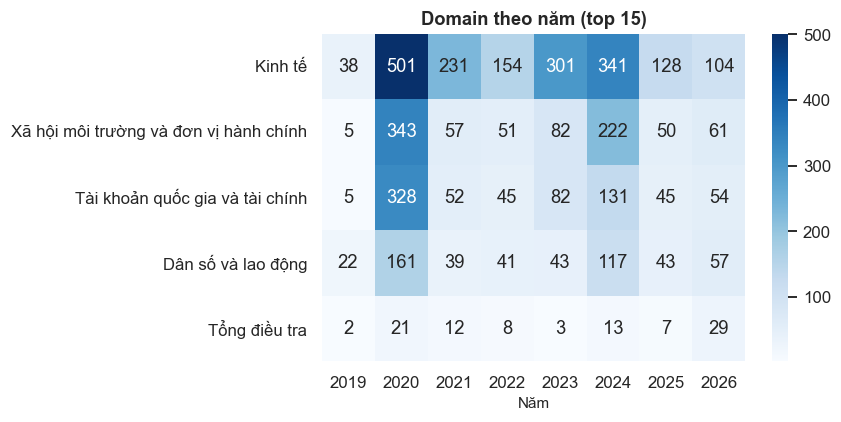

In [4]:
source_timeline(df, atomic_domains)

## 4. Chất lượng dữ liệu

,field,missing,missing_pct
0,comments,2500,100.00
1,original_text,93,3.72
2,claim,0,0.00
3,domain,0,0.00
4,evidence,0,0.00
5,id,0,0.00
6,justification,0,0.00
7,label,0,0.00
8,publish_date,0,0.00
9,source_name,0,0.00


**Trùng lặp và URL**

,khóa,số_dòng_trùng,số_giá_trị_duy_nhất
0,id,0,2500
1,url,0,2500
2,claim,11,2489
3,original_text,96,2311


,chỉ_số,số_bài
0,URL HTTP(S) hợp lệ,2500
1,URL không hợp lệ/thiếu,0
2,Ngày ở tương lai so với hôm nay,0
3,Bài có comments,0


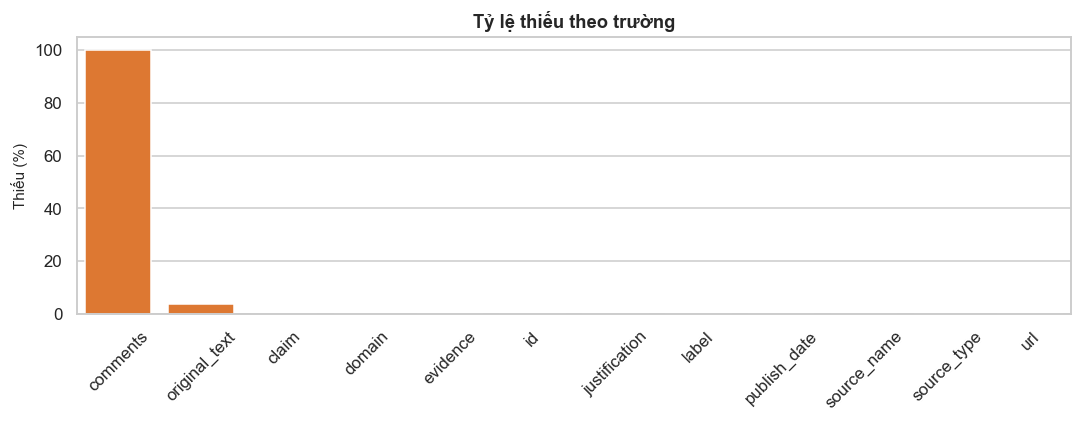

In [5]:
missing = source_quality_analysis(df)

## 5. Độ dài nội dung

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
trường,,,,,,,,,,,
claim_words,"2,500.00",15.07,5.35,4.00,11.00,15.00,18.00,21.00,24.00,31.00,46.00
original_text_words,"2,500.00",49.07,11.45,0.00,49.00,53.00,53.00,55.00,56.00,58.00,64.00
evidence_words,"2,500.00",21.00,0.00,21.00,21.00,21.00,21.00,21.00,21.00,21.00,21.00
justification_words,"2,500.00","2,041.00","2,789.64",34.00,469.00,936.00,"2,462.50","5,750.50","7,854.55","11,888.66","39,565.00"


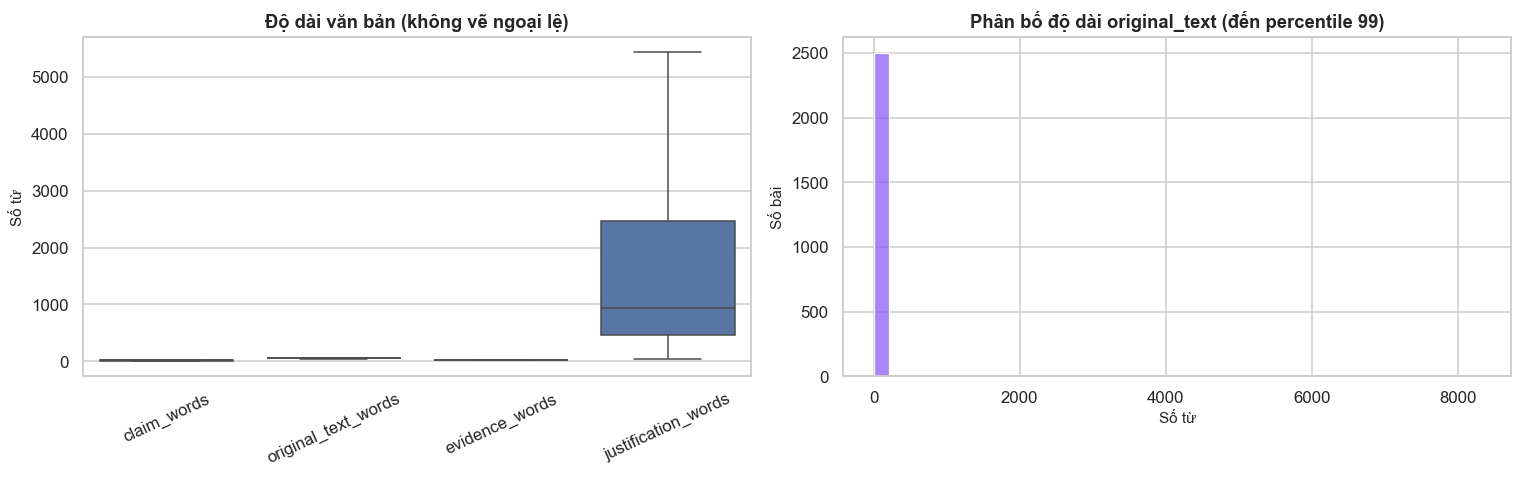

**Độ dài `original_text` theo top domain**

,số_bài,trung_vị,trung_bình,p90
domain_atomic,,,,
Kinh tế,1798,53.00,48.43,54.00
Dân số và lao động,523,52.00,46.82,54.00
Tài khoản quốc gia và tài chính,742,52.00,47.26,55.00
Tổng điều tra,95,52.00,49.00,54.00
Xã hội môi trường và đơn vị hành chính,871,52.00,45.91,55.00


In [6]:
text_summary = source_text_analysis(df, atomic_domains)

## 6. Nhãn, loại nguồn và hostname

In [7]:
source_metadata_analysis(df)

**Nhãn**

,label,số_bài,tỷ_lệ
0,TRUE,2500,1.00


**Loại nguồn**

,source_type,số_bài,tỷ_lệ
0,website,2500,1.00


**Tên nguồn**

,source_name,số_bài,tỷ_lệ
0,GSO/NSO Việt Nam,2500,1.00


**Hostname**

,url_host,số_bài,tỷ_lệ
0,nso.gov.vn,2500,1.00


## 7. Mẫu bài theo domain và nhận xét

In [8]:
samples = source_samples(df, n_per_domain=2)
source_findings(df, atomic_domains)

,domain,publish_date,claim,label,url
0,Dân số và lao động,2019-12-25,"Điều tra biến động dân số, nguồn lao động và kế hoạch hoá gia đình 1/4/2008 - Những kết quả chủ yếu",TRUE,https://www.nso.gov.vn/du-lieu-va-so-lieu-thong-ke/2019/03/dieu-tra-bien-dong-dan-so-nguon-lao-d...
1,Dân số và lao động,2019-12-25,Dự báo dân số Việt Nam 2009-2049,TRUE,https://www.nso.gov.vn/du-lieu-va-so-lieu-thong-ke/2019/03/du-bao-dan-so-viet-nam-2009-2049/
2,Dân số và lao động; Kinh tế; Tài khoản quốc gia và tài chính,2020-09-11,Tờ gấp: Việt Nam - Số liệu thống kê chủ yếu năm 2019,TRUE,https://www.nso.gov.vn/du-lieu-va-so-lieu-thong-ke/2020/01/to-gap-viet-nam-so-lieu-thong-ke-chu-...
3,Dân số và lao động; Kinh tế; Tài khoản quốc gia và tài chính; Xã hội môi trường và đơn vị hành c...,2020-12-11,Kỳ họp lần thứ 10 của Ủy ban Hệ thống Thống kê Cộng đồng ASEAN (ACSS10) (Phiên nội bộ),TRUE,https://www.nso.gov.vn/su-kien/2020/12/ky-hop-lan-thu-10-cua-uy-ban-he-thong-thong-ke-cong-dong-...
4,Dân số và lao động; Kinh tế; Tài khoản quốc gia và tài chính; Xã hội môi trường và đơn vị hành c...,2020-12-18,Phiên toàn thể Kỳ họp lần thứ 10 của Ủy ban Hệ thống Thống kê Cộng đồng ASEAN (ACSS10),TRUE,https://www.nso.gov.vn/su-kien/2020/12/ky-hop-lan-thu-10-cua-uy-ban-he-thong-thong-ke-cong-dong-...
5,Dân số và lao động; Kinh tế; Xã hội môi trường và đơn vị hành chính; Tài khoản quốc gia và tài c...,2020-11-13,Bài phát biểu của Thủ tướng Chính phủ Nguyễn Xuân Phúc tại Hội nghị triển khai kế hoạch công tác...,TRUE,https://www.nso.gov.vn/du-lieu-va-so-lieu-thong-ke/2020/01/bai-phat-bieu-cua-thu-tuong-chinh-phu...
6,Dân số và lao động; Kinh tế; Xã hội môi trường và đơn vị hành chính; Tài khoản quốc gia và tài c...,2023-01-13,Diễn đàn cấp cao về Hệ thống Thống kê cộng đồng ASEAN và Hệ thống Thống kê Việt Nam,TRUE,https://www.nso.gov.vn/su-kien/2020/12/dien-dan-cap-cao-ve-he-thong-thong-ke-cong-dong-asean-va-...
7,Dân số và lao động; Tài khoản quốc gia và tài chính; Kinh tế; Xã hội môi trường và đơn vị hành c...,2025-10-06,Thông cáo báo chí tình hình kinh tế - xã hội quý III và 9 tháng năm 2025,TRUE,https://www.nso.gov.vn/du-lieu-va-so-lieu-thong-ke/2025/10/thong-cao-bao-chi-tinh-hinh-kinh-te-x...
8,Dân số và lao động; Tài khoản quốc gia và tài chính; Xã hội môi trường và đơn vị hành chính,2020-11-17,Quốc hội thông qua mục tiêu tăng trưởng GDP 6% năm 2021,TRUE,https://www.nso.gov.vn/tin-tuc-khac/2020/11/quoc-hoi-thong-qua-muc-tieu-tang-truong-gdp-6-nam-2021/
9,Dân số và lao động; Tổng điều tra,2019-12-25,Kết quả toàn bộ Tổng điều tra Dân số và Nhà ở Việt Nam năm 2009,TRUE,https://www.nso.gov.vn/du-lieu-va-so-lieu-thong-ke/2019/03/ket-qua-toan-bo-tong-dieu-tra-dan-so-...


### Nhận xét tự động
- Có **2,500** bài và **5** domain sau khi tách.
- Domain lớn nhất là **Kinh tế** với **1,798** lượt gán.
- Có **701** bài đa-domain và **0** bài thiếu/không parse được ngày.
- Phân bố nhãn: **TRUE: 2,500**.
- Các nhận xét này là mô tả dữ liệu, không phải kết luận về tính đại diện hay chất lượng nội dung.